# EDA: EIA-860M generator inventory, August 2026

**Goal of the project:** judge whether the near-term solar capacity ramp implied by EIA's *planned* generator inventory is believable, i.e. *which promised megawatts actually arrive?*

This notebook is a first look at a **single monthly snapshot** (`august_generator2026.xlsx`). One snapshot can describe the pipeline (how big, what stage, when it says it will arrive, who reports it) but it **cannot measure slippage**. That needs several inventory months stacked into `generator_snapshot`. The charts below were picked to show:

1. what the data looks like and where its quality traps are,
2. the size and timing of the *apparent* near-term solar ramp, broken down by construction status (the key candidate predictor),
3. how that ramp compares with what has historically been commissioned,
4. how hard the company (NextEra / AES) attribution will be.

## 0. The raw data

Before any cleaning: the rows exactly as they appear in the workbook. Each sheet has a title in row 1, a blank row, then the header row, so `header=2` is the only adjustment made here.

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
RAW_FILE = "data/raw/august_generator2026.xlsx"

print(pd.ExcelFile(RAW_FILE).sheet_names)
raw_planned = pd.read_excel(RAW_FILE, sheet_name="Planned", header=2)
print(f"Planned sheet: {raw_planned.shape[0]:,} rows x {raw_planned.shape[1]} columns")
raw_planned.head(25)

['Operating', 'Planned', 'Retired', 'Canceled or Postponed', 'Operating_PR', 'Planned_PR', 'Retired_PR']


Planned sheet: 2,313 rows x 23 columns


,Entity ID,Entity Name,Plant ID,Plant Name,Google Map,Bing Map,Plant State,County,Balancing Authority Code,Sector,Generator ID,Unit Code,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Energy Source Code,Prime Mover Code,Planned Operation Month,Planned Operation Year,Status,Latitude,Longitude
0,61222,174 Power Global Corp.,63798.0,Atlas,Map,Map,AZ,La Paz,AZPS,IPP Non-CHP,ATL01,NaN,300.0,300.0,300.0,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(V) Under construction, more than 50 percent c...",33.943450,-113.79170
1,65677,Dimension Energy LLC,69834.0,Avon CSG 2 LLC,Map,Map,NY,Livingston,NYIS,IPP Non-CHP,AVON2,NaN,4.1,4.1,4.1,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(TS) Construction complete, but not yet in com...",42.885817,-77.71431
2,65677,Dimension Energy LLC,69841.0,"Bluestar Solar Project, LLC",Map,Map,IL,Montgomery,MISO,IPP Non-CHP,BLUST,NaN,5.0,5.0,5.0,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(U) Under construction, less than or equal to ...",39.150212,-89.45092
3,65677,Dimension Energy LLC,69844.0,"Horseshoe Solar Project, LLC",Map,Map,IL,Montgomery,MISO,IPP Non-CHP,HORSE,NaN,5.0,5.0,5.0,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(V) Under construction, more than 50 percent c...",39.147060,-89.44260
4,65677,Dimension Energy LLC,69848.0,Spillertown CSG 1 LLC,Map,Map,IL,Williamson,MISO,IPP Non-CHP,SPIL1,NaN,5.0,5.0,5.0,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(V) Under construction, more than 50 percent c...",37.761959,-88.92260
5,63689,"Wonderful Renewable Energy, LLC.",70372.0,Lerdo Middle,Map,Map,CA,Kern,CISO,Industrial Non-CHP,LERMI,NaN,2.4,2.4,2.4,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(V) Under construction, more than 50 percent c...",35.506220,-119.16200
6,61194,Generate Capital,70444.0,Cottonwood - IL,Map,Map,IL,Woodford,MISO,IPP Non-CHP,11131,NaN,4.9,4.9,4.9,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(V) Under construction, more than 50 percent c...",40.684739,-89.00338
7,7490,Grand River Dam Authority,165.0,GREC,Map,Map,OK,Mayes,SWPP,Electric Utility,4,NaN,594.0,416.0,436.0,Natural Gas Fired Combustion Turbine,NG,GT,9.0,2026.0,"(TS) Construction complete, but not yet in com...",36.190278,-95.28940
8,7140,Georgia Power Co,708.0,Hammond,Map,Map,GA,Floyd,SOCO,Electric Utility,5,NaN,57.5,57.5,57.5,Batteries,MWH,BA,9.0,2026.0,"(V) Under construction, more than 50 percent c...",34.252800,-85.34560
9,5860,Empire District Electric Co,1239.0,Riverton,Map,Map,KS,Cherokee,SWPP,Electric Utility,13,NaN,13.5,13.6,13.6,Natural Gas Fired Combustion Turbine,NG,GT,9.0,2026.0,"(TS) Construction complete, but not yet in com...",37.072616,-94.69870


In [2]:
# The other main sheets, first 10 rows each
for sheet in ["Operating", "Retired", "Canceled or Postponed"]:
    raw = pd.read_excel(RAW_FILE, sheet_name=sheet, header=2)
    print(f"{sheet}: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
    display(raw.head(10))

Operating: 28,379 rows x 37 columns


,Entity ID,Entity Name,Plant ID,Plant Name,Google Map,Bing Map,Plant State,County,Balancing Authority Code,Sector,Generator ID,Unit Code,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Energy Source Code,Prime Mover Code,Operating Month,Operating Year,Planned Retirement Month,Planned Retirement Year,Status,Nameplate Energy Capacity (MWh),DC Net Capacity (MW),Planned Derate Year,Planned Derate Month,Planned Derate of Summer Capacity (MW),Planned Uprate Year,Planned Uprate Month,Planned Uprate of Summer Capacity (MW),Planned Repower Year,Planned Repower Month,Other Modification Year,Other Modification Month,Latitude,Longitude
0,63560,"Sand Point Generating, LLC",1.0,Sand Point,Map,Map,AK,Aleutians East,NaN,Electric Utility,1,NaN,0.9,0.4,0.4,Petroleum Liquids,DFO,IC,12.0,2000.0,,,(SB) Standby/Backup: available for service but...,,,,,,,,,,,,,55.339722,-160.49720
1,63560,"Sand Point Generating, LLC",1.0,Sand Point,Map,Map,AK,Aleutians East,NaN,Electric Utility,2,NaN,0.9,0.3,0.3,Petroleum Liquids,DFO,IC,12.0,2000.0,,,(OP) Operating,,,,,,,,,,,,,55.339722,-160.49720
2,63560,"Sand Point Generating, LLC",1.0,Sand Point,Map,Map,AK,Aleutians East,NaN,Electric Utility,3,NaN,0.5,0.3,0.3,Petroleum Liquids,DFO,IC,12.0,2010.0,,,(OP) Operating,,,,,,,,,,,,,55.339722,-160.49720
3,63560,"Sand Point Generating, LLC",1.0,Sand Point,Map,Map,AK,Aleutians East,NaN,Electric Utility,5.1,NaN,0.4,0.3,0.3,Petroleum Liquids,DFO,IC,2.0,2023.0,,,(OP) Operating,,,,,,,,,,,,,55.339722,-160.49720
4,63560,"Sand Point Generating, LLC",1.0,Sand Point,Map,Map,AK,Aleutians East,NaN,Electric Utility,WT1,NaN,0.5,0.1,0.1,Onshore Wind Turbine,WND,WT,10.0,2011.0,,,(OS) Out of service and NOT expected to return...,,,,,,,,,,,,,55.339722,-160.49720
5,63560,"Sand Point Generating, LLC",1.0,Sand Point,Map,Map,AK,Aleutians East,NaN,Electric Utility,WT2,NaN,0.5,0.3,0.3,Onshore Wind Turbine,WND,WT,10.0,2011.0,,,(OS) Out of service and NOT expected to return...,,,,,,,,,,,,,55.339722,-160.49720
6,195,Alabama Power Co,2.0,Bankhead Dam,Map,Map,AL,Tuscaloosa,SOCO,Electric Utility,1,NaN,53.9,53,53,Conventional Hydroelectric,WAT,HY,7.0,1963.0,,,(OP) Operating,,,,,,,,,,,,,33.458665,-87.35682
7,195,Alabama Power Co,3.0,Barry,Map,Map,AL,Mobile,SOCO,Electric Utility,1,NaN,153.1,80,80,Natural Gas Steam Turbine,NG,ST,2.0,1954.0,,,(OP) Operating,,,,,,,,,,,,,31.006900,-88.01030
8,195,Alabama Power Co,3.0,Barry,Map,Map,AL,Mobile,SOCO,Electric Utility,2,NaN,153.1,80,80,Natural Gas Steam Turbine,NG,ST,7.0,1954.0,,,(OP) Operating,,,,,,,,,,,,,31.006900,-88.01030
9,195,Alabama Power Co,3.0,Barry,Map,Map,AL,Mobile,SOCO,Electric Utility,4,NaN,403.7,362,362,Conventional Steam Coal,BIT,ST,12.0,1969.0,,,(OP) Operating,,,,,,,,,,,,,31.006900,-88.01030


Retired: 7,338 rows x 26 columns


,Entity ID,Entity Name,Plant ID,Plant Name,Google Map,Bing Map,Plant State,County,Balancing Authority Code,Sector,Generator ID,Unit Code,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Energy Source Code,Prime Mover Code,Operating Month,Operating Year,Retirement Month,Retirement Year,Nameplate Energy Capacity (MWh),DC Net Capacity (MW),Latitude,Longitude
0,5860,Empire District Electric Co,1239,Riverton,Map,Map,KS,Cherokee,SWPP,Electric Utility,10,NaN,16.3,13,16,Natural Gas Fired Combustion Turbine,NG,GT,12,1988,8.0,2026.0,,,37.072616,-94.6987
1,5860,Empire District Electric Co,1239,Riverton,Map,Map,KS,Cherokee,SWPP,Electric Utility,11,NaN,16.3,14,16,Natural Gas Fired Combustion Turbine,NG,GT,11,1988,8.0,2026.0,,,37.072616,-94.6987
2,13157,City of Omaha - (NE),55027,Papillion Creek Wastewater,Map,Map,NE,Sarpy,SWPP,Commercial CHP,951,NaN,0.5,0.5,0.5,Other Waste Biomass,OBG,IC,5,1987,8.0,2026.0,,,41.0772,-95.87
3,13157,City of Omaha - (NE),55027,Papillion Creek Wastewater,Map,Map,NE,Sarpy,SWPP,Commercial CHP,952,NaN,0.5,0.5,0.5,Other Waste Biomass,OBG,IC,5,1987,8.0,2026.0,,,41.0772,-95.87
4,13157,City of Omaha - (NE),55027,Papillion Creek Wastewater,Map,Map,NE,Sarpy,SWPP,Commercial CHP,953,NaN,0.5,0.5,0.5,Other Waste Biomass,OBG,IC,5,1987,8.0,2026.0,,,41.0772,-95.87
5,54878,Oregon Environmental Industries LLC,56461,Dry Creek LFG to Energy Project,Map,Map,OR,Jackson,PACW,Commercial Non-CHP,DC1,NaN,1.6,1.5,1.5,Landfill Gas,LFG,IC,7,2007,7.0,2026.0,,,42.3844,-122.7718
6,54878,Oregon Environmental Industries LLC,56461,Dry Creek LFG to Energy Project,Map,Map,OR,Jackson,PACW,Commercial Non-CHP,DC2,NaN,1.6,1.5,1.5,Landfill Gas,LFG,IC,7,2007,7.0,2026.0,,,42.3844,-122.7718
7,56953,"Bos Dairy, LLC",57625,"Bos Dairy, LLC",Map,Map,IN,Jasper,MISO,Industrial Non-CHP,BOS4,NaN,1.0,0.9,0.9,Natural Gas Internal Combustion Engine,NG,IC,3,2020,7.0,2026.0,,,41.1153,-87.2328
8,14605,City of Peabody - (MA),1678,Waters River,Map,Map,MA,Essex,ISNE,Electric Utility,1,NaN,21.3,16,22,Natural Gas Fired Combustion Turbine,NG,GT,12,1971,6.0,2026.0,,,42.542949,-70.92831
9,21048,Wyandotte Municipal Serv Comm - (MI),1866,Wyandotte,Map,Map,MI,Wayne,MISO,Electric Utility,4,NaN,11.5,10.5,11.5,Natural Gas Steam Turbine,NG,ST,1,1948,6.0,2026.0,,,42.2081,-83.1453


Canceled or Postponed: 1,743 rows x 20 columns


,Entity ID,Entity Name,Plant ID,Plant Name,Google Map,Bing Map,Plant State,County,Balancing Authority Code,Sector,Generator ID,Unit Code,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Energy Source Code,Prime Mover Code,Latitude,Longitude
0,5580,"East Kentucky Power Coop, Inc",54.0,J K Smith,Map,Map,KY,Clark,PJM,Electric Utility,GT11,NaN,98.0,74,98,Natural Gas Fired Combustion Turbine,NG,GT,37.8833,-84.1017
1,5580,"East Kentucky Power Coop, Inc",54.0,J K Smith,Map,Map,KY,Clark,PJM,Electric Utility,GT12,NaN,98.0,74,98,Natural Gas Fired Combustion Turbine,NG,GT,37.8833,-84.1017
2,5580,"East Kentucky Power Coop, Inc",54.0,J K Smith,Map,Map,KY,Clark,PJM,Electric Utility,GT8,NaN,83.0,74,98,Natural Gas Fired Combustion Turbine,NG,GT,37.8833,-84.1017
3,5580,"East Kentucky Power Coop, Inc",54.0,J K Smith,Map,Map,KY,Clark,PJM,Electric Utility,ST1,NaN,329.4,278,278,Conventional Steam Coal,BIT,ST,37.8833,-84.1017
4,986,Aurora Energy LLC,79.0,Chena Power Plant,Map,Map,AK,Fairbanks North Star,NaN,IPP CHP,7,NaN,2.3,2.3,2.3,Conventional Steam Coal,SUB,ST,64.847743,-147.7351
5,21554,Seminole Electric Cooperative Inc,136.0,Seminole (FL),Map,Map,FL,Putnam,SEC,Electric Utility,3,NaN,850.0,750,750,Conventional Steam Coal,BIT,ST,29.733056,-81.63278
6,796,Arizona Electric Pwr Coop Inc,160.0,Apache Station,Map,Map,AZ,Cochise,WALC,Electric Utility,GT7,NaN,51.1,38,38,Natural Gas Fired Combustion Turbine,NG,GT,32.0603,-109.8931
7,796,Arizona Electric Pwr Coop Inc,160.0,Apache Station,Map,Map,AZ,Cochise,WALC,Electric Utility,GT8,NaN,51.1,38,38,Natural Gas Fired Combustion Turbine,NG,GT,32.0603,-109.8931
8,14354,PacifiCorp,299.0,Blundell,Map,Map,UT,Beaver,PACE,Electric Utility,3,NaN,30.0,35,35,Geothermal,GEO,ST,38.4889,-112.8533
9,11208,Los Angeles Department of Water & Power,404.0,Scattergood,Map,Map,CA,Los Angeles,LDWP,Electric Utility,8,NaN,230.0,218,218,Natural Gas Fired Combined Cycle,NG,CT,33.918151,-118.4276


In [3]:
# Bottom of the sheet: a blank row and a long NOTES row that the loader drops
raw_planned.tail(4)

,Entity ID,Entity Name,Plant ID,Plant Name,Google Map,Bing Map,Plant State,County,Balancing Authority Code,Sector,Generator ID,Unit Code,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Energy Source Code,Prime Mover Code,Planned Operation Month,Planned Operation Year,Status,Latitude,Longitude
2309,56789,TBE Montgomery LLC,57472.0,TBE-Montgomery LLC,Map,Map,NY,Orange,NYIS,IPP Non-CHP,CTG,NaN,12.0,11.6,12.0,Other Waste Biomass,OBG,CT,12.0,2039.0,"(U) Under construction, less than or equal to ...",41.4885,-74.2262
2310,56789,TBE Montgomery LLC,57472.0,TBE-Montgomery LLC,Map,Map,NY,Orange,NYIS,IPP Non-CHP,STG,NaN,9.0,7.4,8.1,Other Waste Biomass,OBG,CA,12.0,2039.0,"(U) Under construction, less than or equal to ...",41.4885,-74.2262
2311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2312,NOTES:\nCapacity from facilities with a total ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "src")
from load_eia860m import PLANNED_STATUS_LABELS, PLANNED_STATUS_ORDER, load_workbook

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Status palette: light (early / speculative) -> dark (construction complete)
STATUS_COLORS = dict(zip(PLANNED_STATUS_ORDER, sns.color_palette("YlGnBu", len(PLANNED_STATUS_ORDER) + 1)[1:]))
GROUP_COLORS = {"Planned": "#1f77b4", "Operating": "#2ca02c", "Canceled": "#d62728"}

RAW = Path("data/raw/august_generator2026.xlsx")

## 1. Load and orient

In [5]:
sheets = load_workbook(RAW)
INV = sheets["Planned"]["inventory_month"].iloc[0]
print(f"Inventory month: {INV:%B %Y}\n")
pd.DataFrame({name: {"rows": len(df), "columns": df.shape[1], "MW": df["nameplate_capacity_mw"].sum()}
              for name, df in sheets.items()}).T.astype({"rows": int, "columns": int}).round(0)

Inventory month: August 2026



,rows,columns,MW
Operating,28377,41,1411472.0
Planned,2311,26,288544.0
Retired,7336,28,308166.0
Canceled or Postponed,1741,20,185066.0


In [6]:
op, pl, rt, cx = (sheets[s] for s in ["Operating", "Planned", "Retired", "Canceled or Postponed"])

# Solar = energy source SUN (PV + the rare solar thermal). Batteries are MWH, tracked separately.
is_sun = lambda df: df["energy_source_code"].eq("SUN")
pl_sun, op_sun, cx_sun = pl[is_sun(pl)].copy(), op[is_sun(op)].copy(), cx[is_sun(cx)].copy()

print(f"Planned solar:   {len(pl_sun):>5,} generators  {pl_sun.nameplate_capacity_mw.sum()/1e3:>6.1f} GW")
print(f"Operating solar: {len(op_sun):>5,} generators  {op_sun.nameplate_capacity_mw.sum()/1e3:>6.1f} GW")
print(f"Canceled solar:  {len(cx_sun):>5,} generators  {cx_sun.nameplate_capacity_mw.sum()/1e3:>6.1f} GW")
pl_sun.head(3)

Planned solar:   1,076 generators   122.3 GW
Operating solar: 8,293 generators   169.0 GW
Canceled solar:    643 generators    31.0 GW


,entity_id,entity_name,plant_id,plant_name,plant_state,county,balancing_authority_code,sector,generator_id,unit_code,nameplate_capacity_mw,net_summer_capacity_mw,net_winter_capacity_mw,technology,energy_source_code,prime_mover_code,planned_operation_month,planned_operation_year,status,latitude,longitude,planned_date,status_code,status_label,sheet,inventory_month
0,61222,174 Power Global Corp.,63798,Atlas,AZ,La Paz,AZPS,IPP Non-CHP,ATL01,NaN,300.0,300.0,300.0,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(V) Under construction, more than 50 percent c...",33.943450,-113.79170,2026-08-01,V,"Under construction, more than 50 percent complete",Planned,2026-08-01
1,65677,Dimension Energy LLC,69834,Avon CSG 2 LLC,NY,Livingston,NYIS,IPP Non-CHP,AVON2,NaN,4.1,4.1,4.1,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(TS) Construction complete, but not yet in com...",42.885817,-77.71431,2026-08-01,TS,"Construction complete, but not yet in commerci...",Planned,2026-08-01
2,65677,Dimension Energy LLC,69841,"Bluestar Solar Project, LLC",IL,Montgomery,MISO,IPP Non-CHP,BLUST,NaN,5.0,5.0,5.0,Solar Photovoltaic,SUN,PV,8.0,2026.0,"(U) Under construction, less than or equal to ...",39.150212,-89.45092,2026-08-01,U,"Under construction, less than or equal to 50 p...",Planned,2026-08-01


**Columns available per sheet.** The Planned sheet is narrow: no DC capacity, no storage MWh, no original planned date. It holds only the *current* planned month/year, so date pushes can only be seen by comparing snapshots.

In [7]:
cols = sorted(set().union(*[df.columns for df in sheets.values()]))
pd.DataFrame({name: [c in df.columns for c in cols] for name, df in sheets.items()}, index=cols).replace({True: "✓", False: ""})

,Operating,Planned,Retired,Canceled or Postponed
balancing_authority_code,✓,✓,✓,✓
county,✓,✓,✓,✓
dc_net_capacity_mw,✓,,✓,
energy_source_code,✓,✓,✓,✓
entity_id,✓,✓,✓,✓
entity_name,✓,✓,✓,✓
generator_id,✓,✓,✓,✓
inventory_month,✓,✓,✓,✓
latitude,✓,✓,✓,✓
longitude,✓,✓,✓,✓


## 2. Data quality checks

In [8]:
# Missingness in the planned-solar columns that matter for the analysis
key_cols = ["entity_id", "plant_id", "generator_id", "plant_state", "county", "balancing_authority_code",
            "nameplate_capacity_mw", "planned_date", "status_code", "latitude", "longitude"]
miss = pl_sun[key_cols].isna().mean().mul(100).round(1).rename("% missing (planned solar)")
miss.to_frame()

,% missing (planned solar)
entity_id,0.0
plant_id,0.0
generator_id,0.0
plant_state,0.0
county,0.0
balancing_authority_code,0.0
nameplate_capacity_mw,0.0
planned_date,0.0
status_code,0.0
latitude,0.0


In [9]:
# Identity: (plant_id, generator_id) should be unique within and across inventories in one snapshot
allg = pd.concat([df.assign(inv=name)[["plant_id", "generator_id", "inv"]] for name, df in sheets.items()])
within = {name: df.duplicated(["plant_id", "generator_id"]).sum() for name, df in sheets.items()}
cross = allg[allg.duplicated(["plant_id", "generator_id"], keep=False)].sort_values(["plant_id", "generator_id"])
print("Duplicate keys within sheets:", within)
print(f"Keys appearing in >1 inventory: {cross[['plant_id','generator_id']].drop_duplicates().shape[0]}")
cross.groupby("inv").size().rename("rows with cross-sheet key").to_frame()

Duplicate keys within sheets: {'Operating': np.int64(0), 'Planned': np.int64(0), 'Retired': np.int64(11), 'Canceled or Postponed': np.int64(0)}
Keys appearing in >1 inventory: 1


,rows with cross-sheet key
inv,
Retired,12


`(plant_id, generator_id)` is unique on the Operating, Planned and Canceled sheets. The only collisions are a handful of rows *within* Retired, where a generator ID was reused at a plant. That is a small preview of the identity problem `generator_transition` will have to adjudicate across months.

In [10]:
# Timing sanity: is any planned date already in the past relative to the inventory month?
pl_sun["months_to_cod"] = ((pl_sun.planned_date.dt.year - INV.year) * 12 + (pl_sun.planned_date.dt.month - INV.month))
print(f"Planned solar with planned COD before the inventory month: {(pl_sun.months_to_cod < 0).sum()}")
print(f"Planned COD range: {pl_sun.planned_date.min():%Y-%m} -> {pl_sun.planned_date.max():%Y-%m}")
print("\nPlanned COD month-of-year distribution (count):")
print(pl_sun.planned_date.dt.month.value_counts().sort_index().to_string())

Planned solar with planned COD before the inventory month: 0
Planned COD range: 2026-08 -> 2031-12

Planned COD month-of-year distribution (count):
planned_date
1      39
2      23
3      64
4      38
5      38
6      54
7      51
8      39
9     154
10    153
11    120
12    303


No overdue planned dates: EIA (or respondents) **roll stale dates forward** every month, so a single snapshot never shows a project as late. Delay only becomes visible by comparing snapshots. December is also over-represented, which suggests "end of year" is used as a placeholder target.

In [11]:
# Capacity sanity: zero / tiny / very large values, and nameplate vs net summer capacity
cap = pl_sun.nameplate_capacity_mw
print(cap.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1).to_string())
print(f"\n<= 0 MW: {(cap <= 0).sum()}   < 1 MW: {(cap < 1).sum()}   >= 300 MW: {(cap >= 300).sum()}")
ratio = (pl_sun.net_summer_capacity_mw / cap).replace([np.inf, -np.inf], np.nan)
print(f"Net summer / nameplate: median {ratio.median():.2f}, share != 1: {(ratio.round(3) != 1).mean():.0%}")

count    1076.0
mean      113.6
std       149.7
min         0.2
10%         2.0
25%         4.8
50%        74.5
75%       180.0
90%       300.0
99%       600.0
max      1200.0

<= 0 MW: 0   < 1 MW: 10   >= 300 MW: 121
Net summer / nameplate: median 1.00, share != 1: 4%


## 3. What is in the planned pipeline? (all technologies)

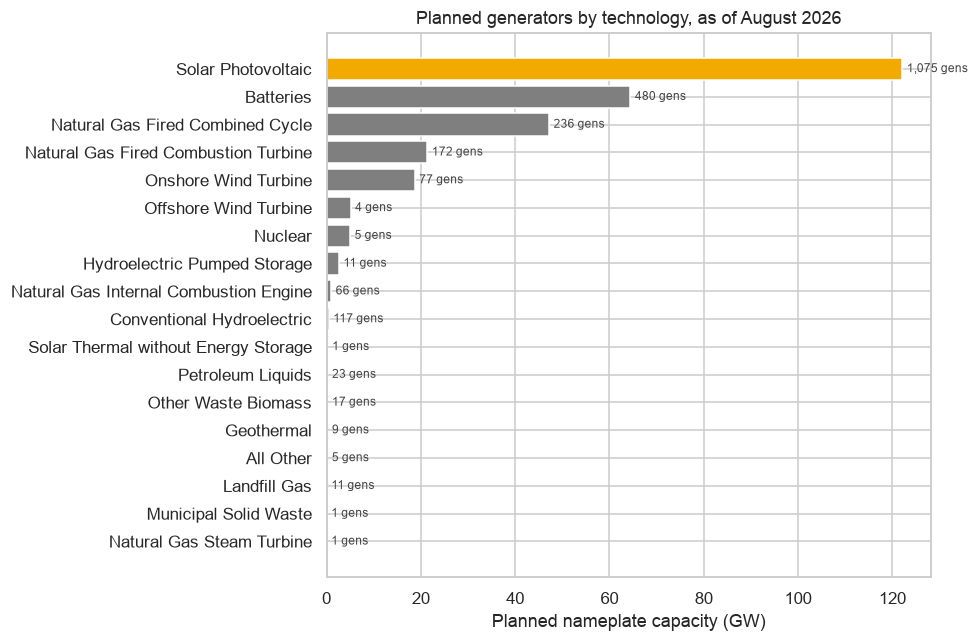

In [12]:
tech = (pl.groupby("technology")["nameplate_capacity_mw"].agg(["sum", "size"])
          .sort_values("sum").rename(columns={"sum": "MW", "size": "generators"}))
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#f2a900" if "Solar" in t else "#7f7f7f" for t in tech.index]
ax.barh(tech.index, tech.MW / 1e3, color=colors)
for y, (mw, n) in enumerate(zip(tech.MW, tech.generators)):
    ax.text(mw / 1e3 + 1, y, f"{n:,} gens", va="center", fontsize=8, color="#444")
ax.set_xlabel("Planned nameplate capacity (GW)")
ax.set_title(f"Planned generators by technology, as of {INV:%B %Y}")
plt.tight_layout(); plt.show()

In [13]:
# Solar + storage hybrids: plants with both a planned SUN and a planned MWH generator
plant_src = pl.groupby("plant_id")["energy_source_code"].agg(set)
hybrid_plants = plant_src[plant_src.apply(lambda s: {"SUN", "MWH"} <= s)].index
pl_sun["hybrid_storage"] = pl_sun.plant_id.isin(hybrid_plants)
share = pl_sun.groupby("hybrid_storage").nameplate_capacity_mw.sum() / pl_sun.nameplate_capacity_mw.sum()
print(f"Planned solar plants with a co-located planned battery: {len(hybrid_plants)}  "
      f"({share.get(True, 0):.0%} of planned solar MW)")

Planned solar plants with a co-located planned battery: 187  (31% of planned solar MW)


## 4. Planned solar by construction status

Status is the main candidate predictor in the hypothesis. The codes go roughly in order: **P** (not started) → **L** (approvals pending) → **T** (approvals received) → **U** (≤50% built) → **V** (>50% built) → **TS** (built, not yet commercial).

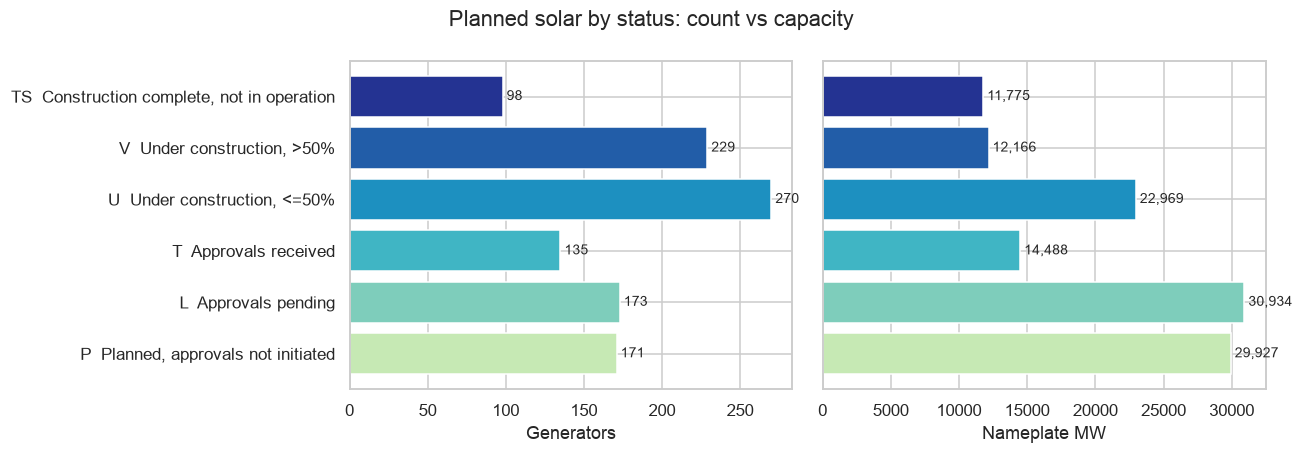

,label,generators,MW,share_MW
status_code,,,,
P,"Planned, approvals not initiated",171,"29,927",24%
L,Approvals pending,173,"30,934",25%
T,Approvals received,135,"14,488",12%
U,"Under construction, <=50%",270,"22,969",19%
V,"Under construction, >50%",229,"12,166",10%
TS,"Construction complete, not in operation",98,"11,775",10%


In [14]:
st = (pl_sun.groupby("status_code")["nameplate_capacity_mw"].agg(MW="sum", generators="size")
           .reindex(PLANNED_STATUS_ORDER))
st["share_MW"] = st.MW / st.MW.sum()
st["label"] = st.index.map(PLANNED_STATUS_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, col, xl in [(axes[0], "generators", "Generators"), (axes[1], "MW", "Nameplate MW")]:
    ax.barh(st.index, st[col], color=[STATUS_COLORS[s] for s in st.index])
    ax.set_xlabel(xl); ax.invert_yaxis()
    for y, v in enumerate(st[col]):
        ax.text(v, y, f" {v:,.0f}", va="center", fontsize=9)
axes[0].set_yticks(range(len(st)), [f"{c}  {PLANNED_STATUS_LABELS[c]}" for c in st.index])
fig.suptitle("Planned solar by status: count vs capacity")
plt.tight_layout(); plt.show()
st[["label", "generators", "MW", "share_MW"]].style.format({"MW": "{:,.0f}", "share_MW": "{:.0%}"})

## 5. The apparent near-term ramp (core chart)

This is the chart the project is meant to *assess rather than just draw*: planned solar MW by the month it says it will start operating, stacked by status. The shaded bands are the 3- and 6-month horizons from the hypothesis.

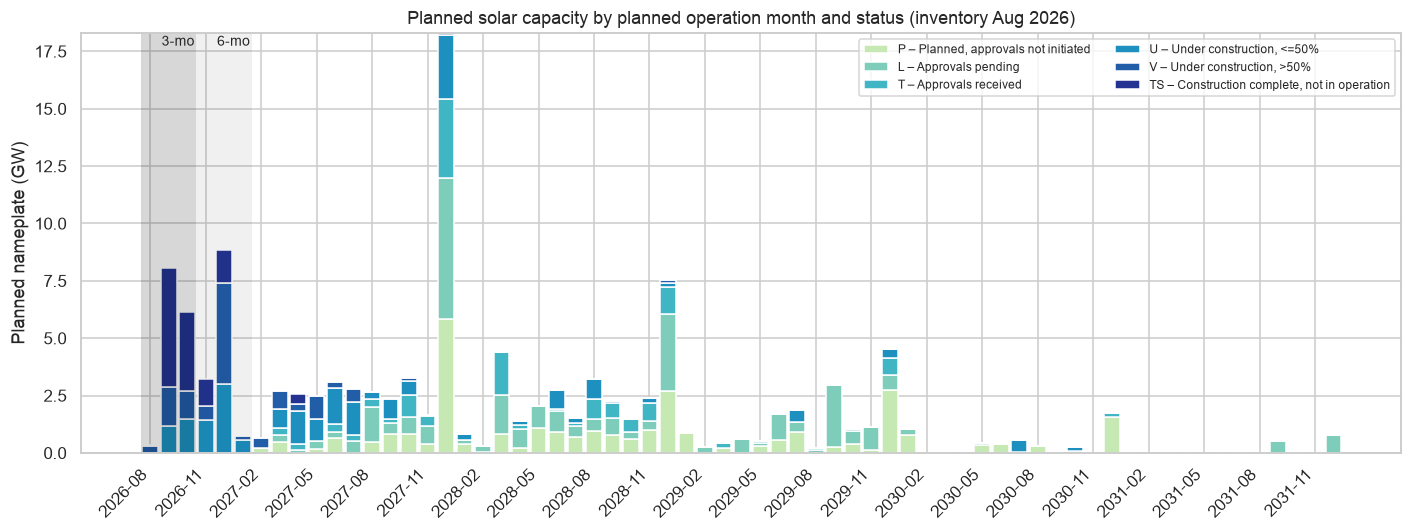

In [15]:
ramp = (pl_sun.pivot_table(index="planned_date", columns="status_code", values="nameplate_capacity_mw",
                           aggfunc="sum", fill_value=0)
              .reindex(columns=PLANNED_STATUS_ORDER, fill_value=0))
ramp = ramp.reindex(pd.date_range(ramp.index.min(), ramp.index.max(), freq="MS"), fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(ramp))
x = np.arange(len(ramp))
for s in PLANNED_STATUS_ORDER:
    ax.bar(x, ramp[s] / 1e3, bottom=bottom, color=STATUS_COLORS[s], label=f"{s} – {PLANNED_STATUS_LABELS[s]}", width=0.85)
    bottom += ramp[s].values / 1e3
for h, a in [(6, 0.06), (3, 0.10)]:
    ax.axvspan(-0.5, h - 0.5, color="black", alpha=a, lw=0)
    ax.text(h - 0.6, bottom.max() * 0.97, f"{h}-mo", ha="right", fontsize=9)
ax.set_xticks(x[::3], [d.strftime("%Y-%m") for d in ramp.index[::3]], rotation=45, ha="right")
ax.set_ylabel("Planned nameplate (GW)")
ax.set_title(f"Planned solar capacity by planned operation month and status (inventory {INV:%b %Y})")
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

In [16]:
horizon = pd.cut(pl_sun.months_to_cod, [-1, 2, 5, 11, 23, 999], labels=["0–3 mo", "3–6 mo", "6–12 mo", "12–24 mo", "24+ mo"])
summary = (pl_sun.assign(horizon=horizon)
                  .pivot_table(index="horizon", columns="status_code", values="nameplate_capacity_mw",
                               aggfunc="sum", fill_value=0, observed=False)
                  .reindex(columns=PLANNED_STATUS_ORDER, fill_value=0))
summary["total_MW"] = summary.sum(axis=1)
summary["cum_GW"] = summary.total_MW.cumsum() / 1e3
summary.round(0)

status_code,P,L,T,U,V,TS,total_MW,cum_GW
horizon,,,,,,,,
0–3 mo,0.0,0.0,0.0,2671.0,3198.0,8667.0,14536.0,15.0
3–6 mo,0.0,0.0,0.0,4978.0,5211.0,2668.0,12858.0,27.0
6–12 mo,1505.0,1514.0,1184.0,6276.0,3350.0,440.0,14268.0,42.0
12–24 mo,12532.0,14921.0,7700.0,6101.0,294.0,0.0,41547.0,83.0
24+ mo,15890.0,14499.0,5603.0,2943.0,113.0,0.0,39049.0,122.0


## 6. Status × time-to-COD: where is the ramp fragile?

If schedules were reliable, projects due within a few months would mostly be **U/V/TS**. Any capacity in the top-left of this grid (early status, near COD) would be "promised" soon without construction having started.

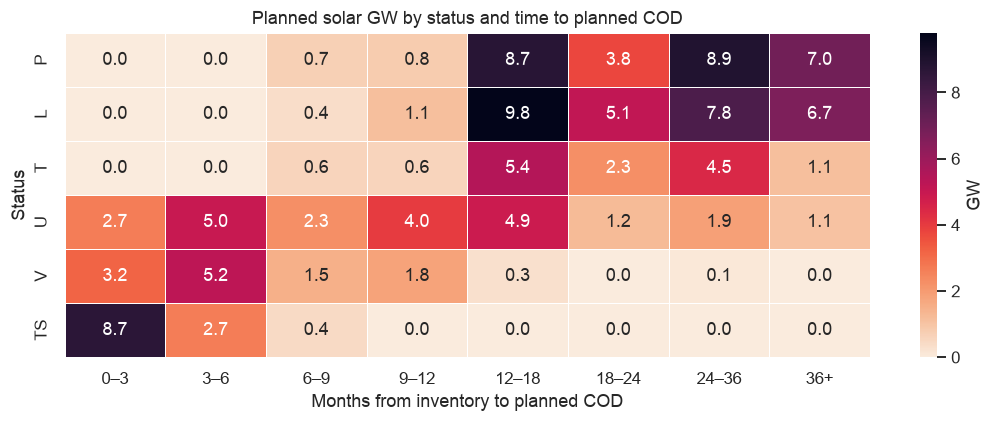

Due within 6 months: 27.4 GW; of which not yet under construction (P/L/T): 0.0 GW (0%)


In [17]:
bins = [-1, 2, 5, 8, 11, 17, 23, 35, 999]
labels = ["0–3", "3–6", "6–9", "9–12", "12–18", "18–24", "24–36", "36+"]
heat = (pl_sun.assign(h=pd.cut(pl_sun.months_to_cod, bins, labels=labels))
              .pivot_table(index="status_code", columns="h", values="nameplate_capacity_mw",
                           aggfunc="sum", fill_value=0, observed=False)
              .reindex(PLANNED_STATUS_ORDER) / 1e3)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="rocket_r", cbar_kws={"label": "GW"}, ax=ax, linewidths=.5)
ax.set_xlabel("Months from inventory to planned COD"); ax.set_ylabel("Status")
ax.set_title("Planned solar GW by status and time to planned COD")
plt.tight_layout(); plt.show()

near = pl_sun[pl_sun.months_to_cod <= 5]
early = near[near.status_code.isin(["P", "L", "T"])]
print(f"Due within 6 months: {near.nameplate_capacity_mw.sum()/1e3:.1f} GW; "
      f"of which not yet under construction (P/L/T): {early.nameplate_capacity_mw.sum()/1e3:.1f} GW "
      f"({early.nameplate_capacity_mw.sum()/near.nameplate_capacity_mw.sum():.0%})")

**Finding:** in this snapshot, *no* capacity due within 6 months is still at P/L/T, and no early-status project has a COD under 6 months. Status and planned date look internally consistent, probably because respondents push the date whenever construction has not started. So "early status + near date" is **not** where the risk shows up in a single snapshot. The tension that *is* visible is **U (≤50% built) with a COD within 3 months**: half-built projects that would have to finish construction and commission within a quarter. That is the near-term slice to watch first.

In [18]:
# Near-term, less-than-half-built projects: good first candidates for the evidence ledger
fragile = pl_sun[(pl_sun.months_to_cod <= 2) & (pl_sun.status_code == "U")]
print(f"U-status solar due within 3 months: {len(fragile)} generators, {fragile.nameplate_capacity_mw.sum()/1e3:.1f} GW "
      f"({fragile.nameplate_capacity_mw.sum()/pl_sun.loc[pl_sun.months_to_cod <= 2, 'nameplate_capacity_mw'].sum():.0%} of 0–3 month MW)")
(fragile.sort_values("nameplate_capacity_mw", ascending=False)
        [["entity_name", "plant_name", "plant_state", "generator_id", "nameplate_capacity_mw", "status_code", "planned_date"]]
        .head(15))

U-status solar due within 3 months: 41 generators, 2.7 GW (18% of 0–3 month MW)


,entity_name,plant_name,plant_state,generator_id,nameplate_capacity_mw,status_code,planned_date
196,Greenbacker Renewable Energy Corporation,Hecate Energy Cider Solar LLC,NY,11111,557.0,U,2026-10-01
243,Public Service Co of Colorado,Arroyo Solar,CO,ARY1,335.0,U,2026-10-01
230,Mammoth Central II LLC,Mammoth Central II Solar Facility,IN,MC201,300.0,U,2026-10-01
104,Sypert Branch Solar LLC,Sypert Branch Solar,TX,SYPRT,293.9,U,2026-09-01
294,"Rumble Solar, LLC",Rumble Solar,OK,RUS,250.0,U,2026-10-01
77,Copia Power,Centennial Flats,AZ,CFPV3,166.7,U,2026-09-01
53,Birch Creek Development,Elm Flats Solar,TX,ELMFL,125.0,U,2026-09-01
45,"Hart Solar Partners, LLC",Hart Solar Project,MI,HS1,120.0,U,2026-09-01
43,"IP Aramis, LLC",Aramis I Solar Project,CA,IPAR1,100.0,U,2026-09-01
27,Naturgy Solar Operation USA LLC,Mark Center Solar Project,OH,MRC1,90.0,U,2026-09-01


## 7. Historical baseline: how much solar actually came online?

The operating sheet records each generator's actual operating month. That gives a run-rate to compare the planned pipeline against. (Caveat: this is survivors only. Generators that came online and later retired sit on the Retired sheet.)

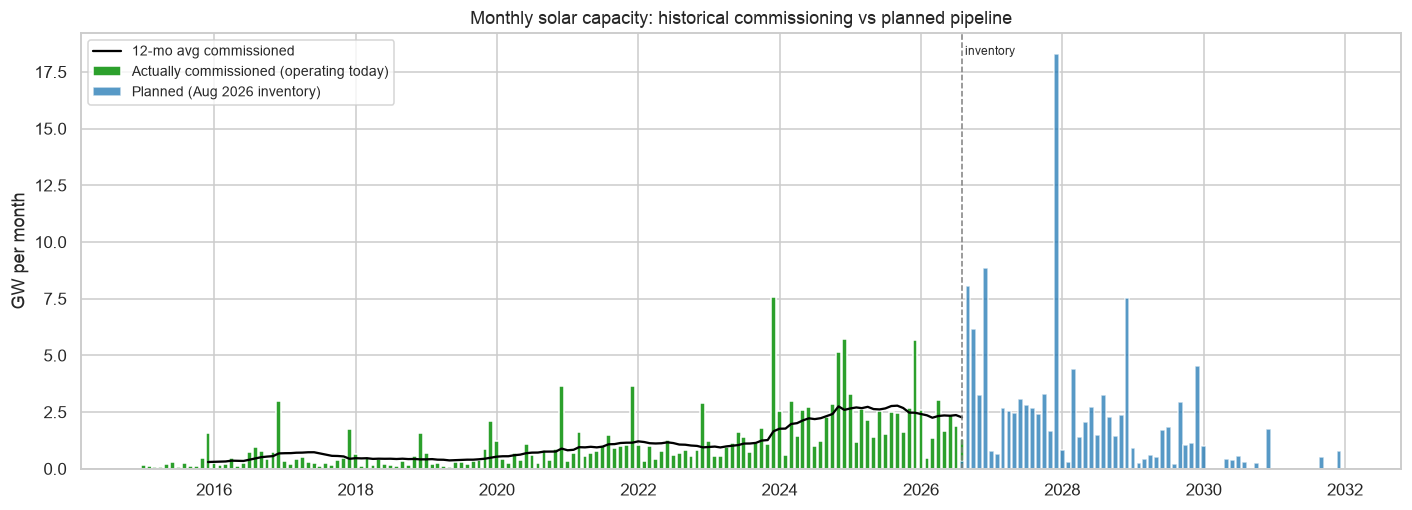

In [19]:
hist = (op_sun[op_sun.operating_date >= "2015-01-01"]
        .groupby(op_sun.operating_date.dt.to_period("M"))["nameplate_capacity_mw"].sum())
hist.index = hist.index.to_timestamp()
plan_m = pl_sun.groupby("planned_date")["nameplate_capacity_mw"].sum()

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(hist.index, hist / 1e3, width=25, color=GROUP_COLORS["Operating"], label="Actually commissioned (operating today)")
ax.bar(plan_m.index, plan_m / 1e3, width=25, color=GROUP_COLORS["Planned"], alpha=.75, label="Planned (Aug 2026 inventory)")
ax.plot(hist.rolling(12).mean().index, hist.rolling(12).mean() / 1e3, color="black", lw=1.5, label="12-mo avg commissioned")
ax.axvline(INV, color="grey", ls="--", lw=1); ax.text(INV, ax.get_ylim()[1] * .95, " inventory", fontsize=8)
ax.set_ylabel("GW per month"); ax.legend(loc="upper left", fontsize=9)
ax.set_title("Monthly solar capacity: historical commissioning vs planned pipeline")
plt.tight_layout(); plt.show()

In [20]:
annual = pd.DataFrame({
    "commissioned_GW": op_sun.groupby(op_sun.operating_date.dt.year).nameplate_capacity_mw.sum() / 1e3,
    "planned_GW": pl_sun.groupby(pl_sun.planned_date.dt.year).nameplate_capacity_mw.sum() / 1e3,
}).loc[2015:].fillna(0)
annual.loc[INV.year, "note"] = f"commissioned = Jan–{INV:%b} only; planned = rest of year"
annual.round(1)

,commissioned_GW,planned_GW,note
2015,3.5,0.0,NaN
2016,8.1,0.0,NaN
2017,5.3,0.0,NaN
2018,5.0,0.0,NaN
2019,5.9,0.0,NaN
2020,10.7,0.0,NaN
2021,13.8,0.0,NaN
2022,11.3,0.0,NaN
2023,19.8,0.0,NaN
2024,31.2,0.0,NaN


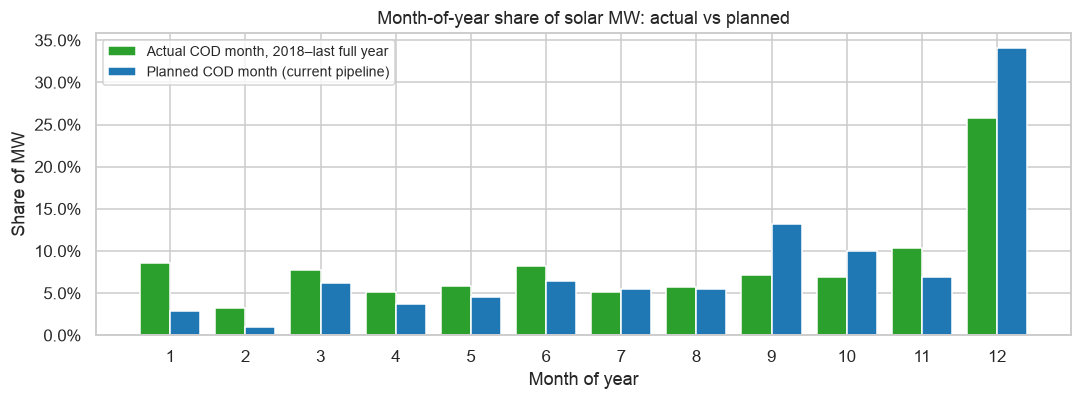

In [21]:
# Seasonality of actual commissioning: is there a year-end (Q4 / December) rush?
seas = (op_sun[op_sun.operating_date.between("2018-01-01", f"{INV.year - 1}-12-31")]
        .groupby(op_sun.operating_date.dt.month).nameplate_capacity_mw.sum())
seas_plan = pl_sun.groupby(pl_sun.planned_date.dt.month).nameplate_capacity_mw.sum()
fig, ax = plt.subplots(figsize=(10, 3.8))
w = 0.4
ax.bar(seas.index - w/2, seas / seas.sum(), w, color=GROUP_COLORS["Operating"], label="Actual COD month, 2018–last full year")
ax.bar(seas_plan.index + w/2, seas_plan / seas_plan.sum(), w, color=GROUP_COLORS["Planned"], label="Planned COD month (current pipeline)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.set_xticks(range(1, 13))
ax.set_xlabel("Month of year"); ax.set_ylabel("Share of MW"); ax.legend(fontsize=9)
ax.set_title("Month-of-year share of solar MW: actual vs planned")
plt.tight_layout(); plt.show()

## 8. Geography

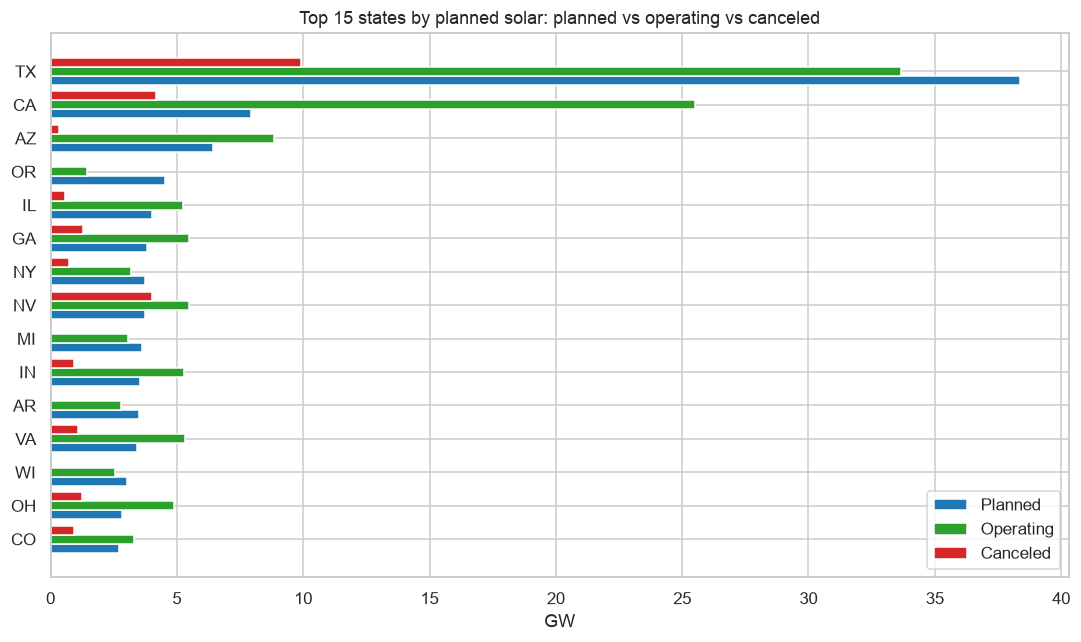

In [22]:
state = pd.DataFrame({
    "planned_GW": pl_sun.groupby("plant_state").nameplate_capacity_mw.sum() / 1e3,
    "operating_GW": op_sun.groupby("plant_state").nameplate_capacity_mw.sum() / 1e3,
    "canceled_GW": cx_sun.groupby("plant_state").nameplate_capacity_mw.sum() / 1e3,
}).fillna(0).sort_values("planned_GW", ascending=False)
top = state.head(15)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(top)); h = 0.27
for i, (col, name) in enumerate([("planned_GW", "Planned"), ("operating_GW", "Operating"), ("canceled_GW", "Canceled")]):
    ax.barh(y + (i - 1) * h, top[col], h, color=GROUP_COLORS[name], label=name)
ax.set_yticks(y, top.index); ax.set_xlabel("GW"); ax.legend()
ax.set_title("Top 15 states by planned solar: planned vs operating vs canceled")
plt.tight_layout(); plt.show()

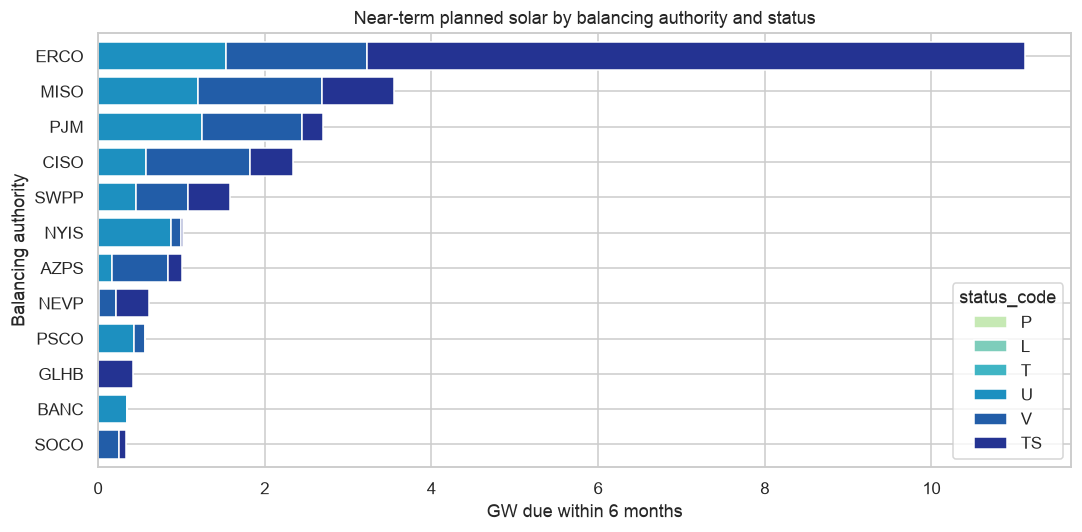

In [23]:
# Near-term (≤6 mo) planned solar by balancing authority and status, which shows where the ramp is concentrated
ba = (near.pivot_table(index="balancing_authority_code", columns="status_code", values="nameplate_capacity_mw",
                       aggfunc="sum", fill_value=0)
          .reindex(columns=PLANNED_STATUS_ORDER, fill_value=0))
ba = ba.loc[ba.sum(axis=1).sort_values(ascending=False).index[:12]][::-1] / 1e3
ax = ba.plot.barh(stacked=True, color=[STATUS_COLORS[s] for s in ba.columns], figsize=(10, 5), width=.8)
ax.set_xlabel("GW due within 6 months"); ax.set_ylabel("Balancing authority")
ax.set_title("Near-term planned solar by balancing authority and status")
plt.tight_layout(); plt.show()

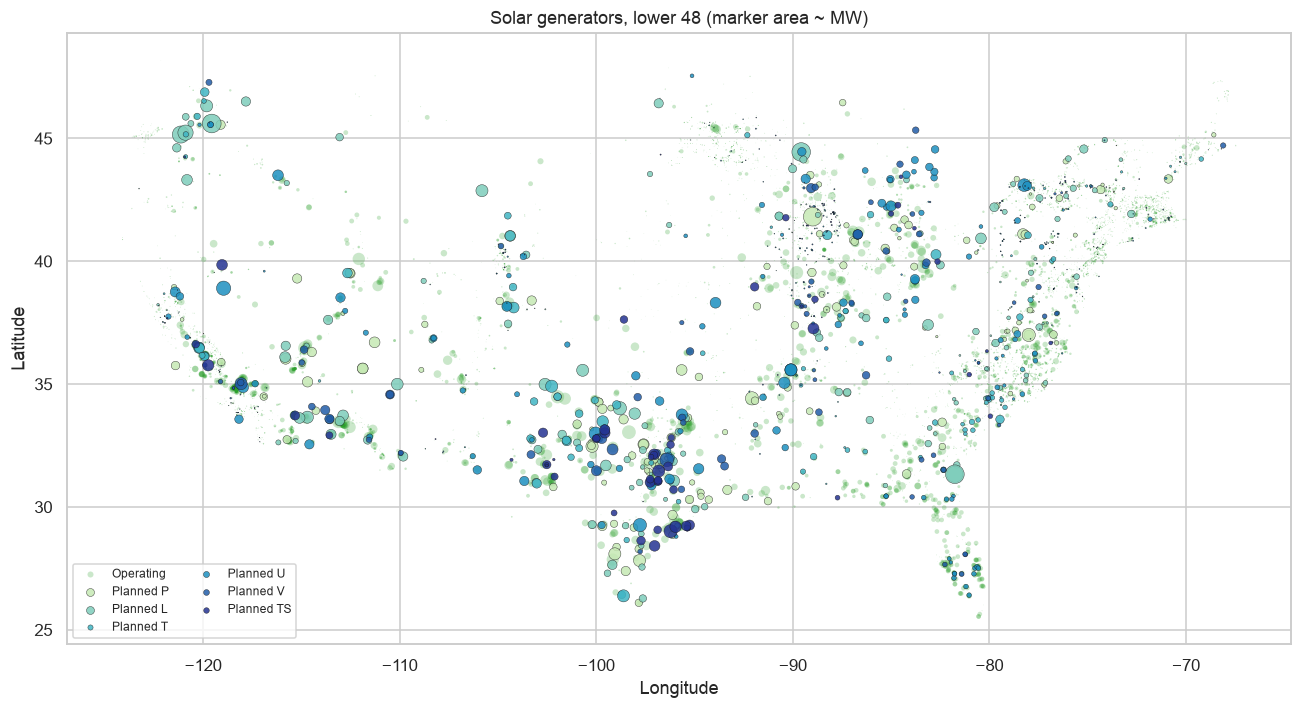

In [24]:
fig, ax = plt.subplots(figsize=(12, 7))
lower48 = lambda df: df[df.longitude.between(-125, -66) & df.latitude.between(24, 50)]
o, p = lower48(op_sun), lower48(pl_sun)
ax.scatter(o.longitude, o.latitude, s=o.nameplate_capacity_mw / 8, c=GROUP_COLORS["Operating"], alpha=.25, lw=0, label="Operating")
for s in PLANNED_STATUS_ORDER:
    q = p[p.status_code == s]
    ax.scatter(q.longitude, q.latitude, s=q.nameplate_capacity_mw / 8, color=STATUS_COLORS[s], edgecolor="k", lw=.3, alpha=.85, label=f"Planned {s}")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_aspect(1.25)
ax.legend(markerscale=.6, fontsize=8, loc="lower left", ncol=2)
ax.set_title("Solar generators, lower 48 (marker area ~ MW)")
plt.tight_layout(); plt.show()

## 9. Project size and concentration

Capacity-weighted error is dominated by large projects, so it is worth knowing how concentrated the planned MW is.

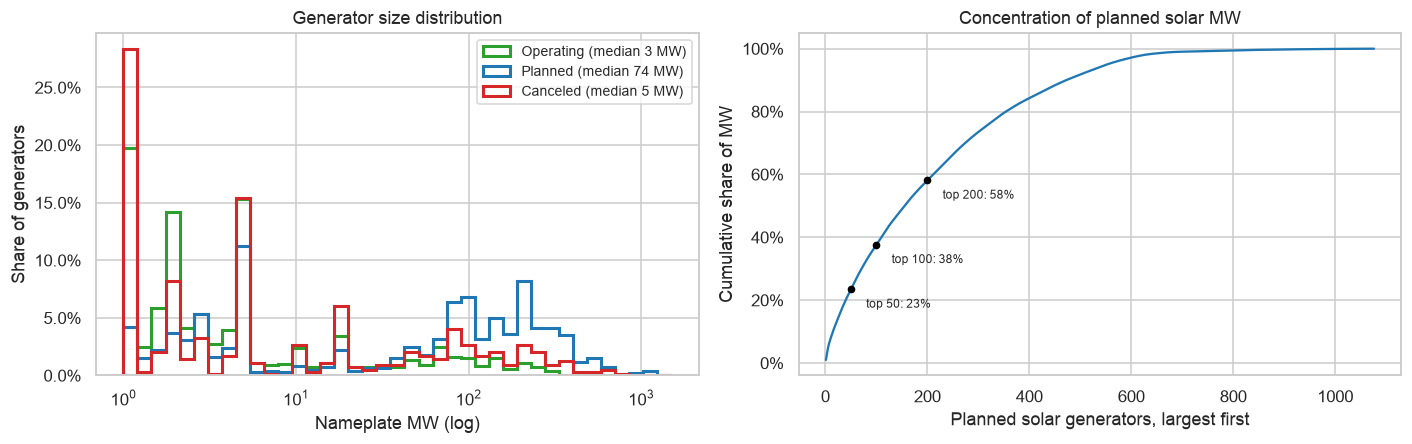

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
logbins = np.logspace(0, np.log10(1500), 40)
for df, name in [(op_sun, "Operating"), (pl_sun, "Planned"), (cx_sun, "Canceled")]:
    axes[0].hist(df.nameplate_capacity_mw.clip(lower=1), bins=logbins, histtype="step", lw=2,
                 weights=np.full(len(df), 1 / len(df)), color=GROUP_COLORS[name],
                 label=f"{name} (median {df.nameplate_capacity_mw.median():.0f} MW)")
axes[0].set_xscale("log"); axes[0].set_xlabel("Nameplate MW (log)"); axes[0].set_ylabel("Share of generators")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[0].legend(fontsize=9)
axes[0].set_title("Generator size distribution")

s = pl_sun.nameplate_capacity_mw.sort_values(ascending=False).reset_index(drop=True)
cum = s.cumsum() / s.sum()
axes[1].plot(np.arange(1, len(s) + 1), cum, color=GROUP_COLORS["Planned"])
for n in [50, 100, 200]:
    axes[1].plot(n, cum[n - 1], "o", color="black", ms=4)
    axes[1].annotate(f"top {n}: {cum[n-1]:.0%}", (n, cum[n - 1]), xytext=(10, -12), textcoords="offset points", fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_xlabel("Planned solar generators, largest first"); axes[1].set_ylabel("Cumulative share of MW")
axes[1].set_title("Concentration of planned solar MW")
plt.tight_layout(); plt.show()

## 10. Cancellations

The *Canceled or Postponed* sheet has **no dates**: no cancellation month and no originally planned COD. So it shows how much has been abandoned, but not when or after how much delay. The timing of cancellation (the competing risk in the survival model) has to come from seeing a generator leave the Planned sheet between monthly snapshots.

In [26]:
cx_rate = (state.assign(cancel_ratio=state.canceled_GW / (state.planned_GW + state.canceled_GW))
                .query("planned_GW + canceled_GW > 1").sort_values("cancel_ratio", ascending=False))
print("Canceled / (planned + canceled) solar GW, states with >1 GW combined:")
cx_rate[["planned_GW", "canceled_GW", "cancel_ratio"]].head(15).style.format(
    {"planned_GW": "{:.1f}", "canceled_GW": "{:.1f}", "cancel_ratio": "{:.0%}"})

Canceled / (planned + canceled) solar GW, states with >1 GW combined:


,planned_GW,canceled_GW,cancel_ratio
plant_state,,,
NV,3.7,4.0,52%
NC,1.6,1.3,45%
CA,7.9,4.2,34%
OH,2.8,1.2,31%
PA,2.0,0.8,28%
GA,3.8,1.3,25%
CO,2.7,0.9,25%
VA,3.4,1.1,24%
SC,1.7,0.5,21%


## 11. Entities: the NextEra / AES lens

`entity_name` is the **reporting operator/respondent**, not the economic owner. Large developers often report through project-level LLCs, so a name search finds only part of their pipeline.

644 distinct reporting entities for planned solar; top 15 hold 27% of MW


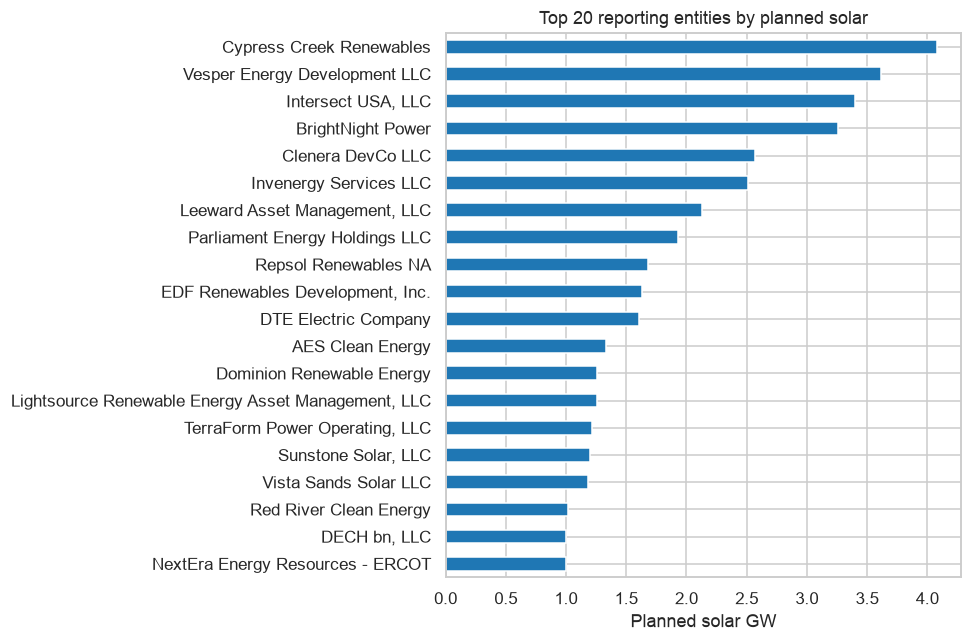

In [27]:
ent = (pl_sun.groupby("entity_name").nameplate_capacity_mw.agg(MW="sum", generators="size")
              .sort_values("MW", ascending=False))
print(f"{ent.shape[0]} distinct reporting entities for planned solar; top 15 hold {ent.MW.head(15).sum()/ent.MW.sum():.0%} of MW")
ax = (ent.head(20).MW[::-1] / 1e3).plot.barh(figsize=(9, 6), color=GROUP_COLORS["Planned"])
ax.set_xlabel("Planned solar GW"); ax.set_ylabel(""); ax.set_title("Top 20 reporting entities by planned solar")
plt.tight_layout(); plt.show()

In [28]:
TARGETS = {
    "NextEra": r"next\s?era|florida power & light|\bFPL\b|gulf power",
    "AES": r"\bAES\b|indianapolis power|dayton power",
}
def tag(name):
    for k, pat in TARGETS.items():
        if pd.Series([name]).str.contains(pat, case=False, regex=True).iat[0]:
            return k
    return None

for df in (pl_sun, op_sun, cx_sun):
    df["target_parent"] = df.entity_name.map(tag)

hits = pd.concat([df.assign(group=g) for df, g in [(pl_sun, "Planned"), (op_sun, "Operating"), (cx_sun, "Canceled")]])
hits = hits[hits.target_parent.notna()]
print("Entity-name variants matched (all solar sheets):")
print(hits.groupby(["target_parent", "entity_name", "group"]).nameplate_capacity_mw.agg(["size", "sum"]).round(0).to_string())

Entity-name variants matched (all solar sheets):
                                                                 size     sum
target_parent entity_name                             group                  
AES           AES Clean Energy                        Canceled      1    20.0
                                                      Operating    43  2453.0
                                                      Planned      16  1334.0
              AES Distributed Energy                  Canceled      2     3.0
                                                      Operating   217  2885.0
                                                      Planned       3   132.0
              AES Griggs Solar, LLC                   Operating     1     2.0
NextEra       Florida Power & Light Co                Operating   122  8829.0
                                                      Planned      13   968.0
              NextEra Blythe Solar Energy Center, LLC Canceled      4   797.0
              N

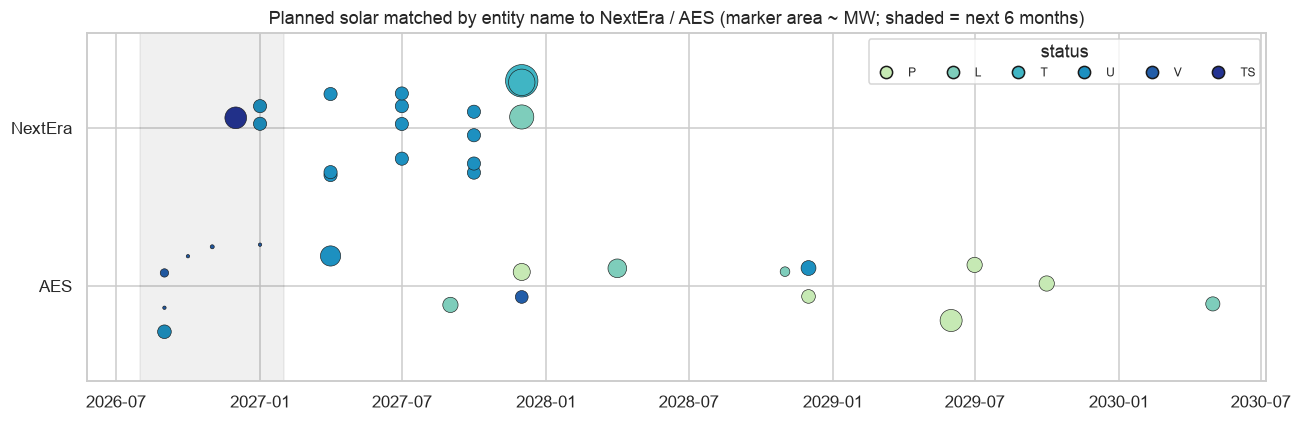

Name-matched planned solar: 3.6 GW = 3.0% of the national pipeline


In [29]:
tp = pl_sun[pl_sun.target_parent.notna()].copy()
parents = sorted(tp.target_parent.unique())
rng = np.random.default_rng(0)
tp["y"] = tp.target_parent.map({p: i for i, p in enumerate(parents)}) + rng.uniform(-.3, .3, len(tp))
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(tp.planned_date, tp.y, s=tp.nameplate_capacity_mw, c=tp.status_code.map(STATUS_COLORS), edgecolor="k", lw=.4)
ax.set_yticks(range(len(parents)), parents); ax.set_ylim(-.6, len(parents) - .4)
ax.axvspan(INV, INV + pd.DateOffset(months=6), color="black", alpha=.06)
ax.set_title("Planned solar matched by entity name to NextEra / AES (marker area ~ MW; shaded = next 6 months)")
handles = [plt.Line2D([], [], marker="o", ls="", markersize=8, markerfacecolor=STATUS_COLORS[s], markeredgecolor="k", label=s)
           for s in PLANNED_STATUS_ORDER]
ax.legend(handles=handles, title="status", fontsize=8, ncol=6, loc="upper right")
plt.tight_layout(); plt.show()
print(f"Name-matched planned solar: {tp.nameplate_capacity_mw.sum()/1e3:.1f} GW "
      f"= {tp.nameplate_capacity_mw.sum()/pl_sun.nameplate_capacity_mw.sum():.1%} of the national pipeline")

NextEra is well known as the largest U.S. renewable developer, so a name match that finds only a small slice of the planned pipeline is evidence that **most of its projects report under project-LLC entity names**. Company attribution will need the EIA-860 annual *Owner* schedule (Schedule 4) plus SEC subsidiary lists, and it may trip the CLAUDE.md abandon rule (>10% of pilot MW with unresolved ownership).

## 12. Takeaways and next steps

**What this snapshot tells us**
- **The apparent ramp is steep.** About 27 GW of solar is scheduled for Sep 2026–Feb 2027, roughly 4–5 GW/month against a historical 12-month average of about 2.5 GW/month. 2027 is planned at about 43 GW versus a record of about 31 GW (2024). Either the build rate jumps or a lot of this slips.
- **All ≤6-month capacity is already under construction or complete (U/V/TS).** Status and date are consistent in one snapshot, so early status is not a near-term red flag here. The visible tension is the ~2.7 GW of *≤50% built* (U) capacity due within 3 months (Section 6).
- **Planned dates are never in the past.** Stale dates get rolled forward, so **delay is invisible in one snapshot**.
- **Placeholder dates:** planned COD is 34% December versus 26% for actual CODs, and Dec 2027 alone holds ~18 GW, mostly P/L/T. Year-end targets look like defaults rather than schedules.
- **Concentration:** the largest 200 of ~1,076 planned solar generators hold ~58% of MW. Planned projects are utility-scale (median ~74 MW) while most operating and canceled rows are small (median 3–5 MW), so capacity-weighted metrics, and a 20–40 project evidence ledger, will be driven by a small set.
- **Reporting entity ≠ owner.** Name matching ties only ~3% of planned solar MW to NextEra/AES, far below their market share. Most of their projects report through project LLCs.

**What it cannot tell us**
- Date pushes, status progressions, disappearances, renumbering, cancellation timing: all of these need multiple inventory months.

**Next steps**
1. Download 3 more EIA-860M archives (e.g. Jan 2024, Jul 2024, Jan 2025) into `data/raw/` and stack them with `load_workbook` into a prototype `generator_snapshot`.
2. Freeze one cohort, e.g. **Texas planned solar as of Jan 2024**, the largest pipeline (ERCOT), and trace each generator forward: operating / still planned (date pushed?) / canceled / vanished.
3. Pull the EIA-860 annual Schedule 4 (ownership) to test how much of the cohort can be tied to NextEra/AES.